# STEP 1: Import Dataset + Train-Test Split

### Cell 1: Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Cell 2: Load Dataset

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

### Cell 3: Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Cell 4: Feature Scaling

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# STEP 2: Perceptron (Single Layer)

### Cell 5: Train Perceptron

In [5]:
from sklearn.linear_model import Perceptron

per_model = Perceptron()

per_model.fit(X_train, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


### Cell 6: Predictions

In [6]:
y_pred_per = per_model.predict(X_test)

# STEP 3: Evaluation (Perceptron)

### Cell 7: Accuracy

In [7]:
from sklearn.metrics import accuracy_score

print("Perceptron Accuracy:", accuracy_score(y_test, y_pred_per))

Perceptron Accuracy: 0.9814814814814815


### Cell 8: Confusion Matrix

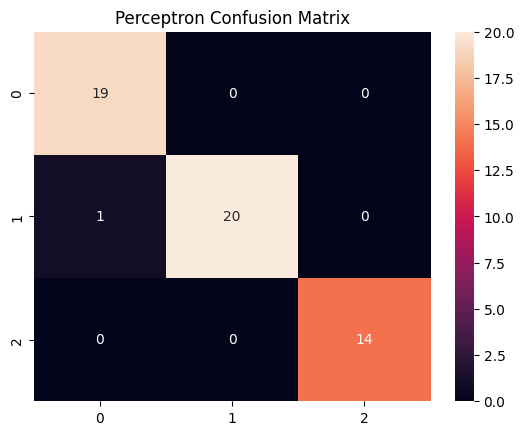

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_per)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Perceptron Confusion Matrix")
plt.show()

# STEP 4: Limitations of Perceptron

### Cell 9:

In [9]:
print("\n===== LIMITATIONS =====\n")

print("1. Works only for linearly separable data.")
print("2. Cannot learn complex decision boundaries.")
print("3. May fail when data overlaps.")


===== LIMITATIONS =====

1. Works only for linearly separable data.
2. Cannot learn complex decision boundaries.
3. May fail when data overlaps.


# STEP 5: Multilayer Perceptron (MLP)

### Cell 10: Train MLP

In [10]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=500)

mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


### Cell 11: Predictions

In [11]:
y_pred_mlp = mlp.predict(X_test)

# STEP 6: Evaluation (MLP)

### Cell 12: Metrics

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_mlp, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_mlp, average='weighted'))

MLP Accuracy: 0.9814814814814815
Precision: 0.982716049382716
Recall: 0.9814814814814815
F1 Score: 0.9815749306918357


### Cell 13: Confusion Matrix

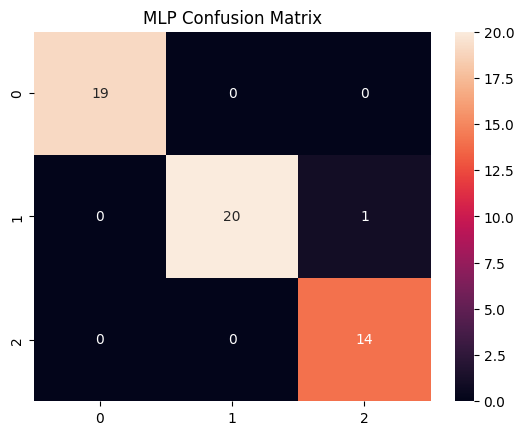

In [13]:
cm = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("MLP Confusion Matrix")
plt.show()

# STEP 7: Compare Perceptron vs MLP

### Cell 14:

In [14]:
results = pd.DataFrame({
    "Model": ["Perceptron", "MLP"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_per),
        accuracy_score(y_test, y_pred_mlp)
    ]
})

print(results)

        Model  Accuracy
0  Perceptron  0.981481
1         MLP  0.981481


### Cell 15: Visualization

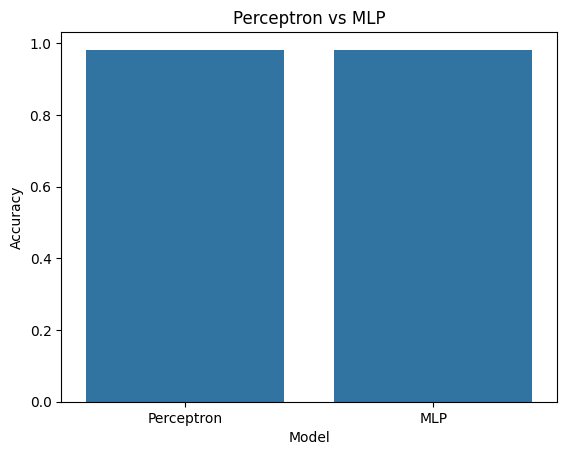

In [15]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Perceptron vs MLP")
plt.show()

# STEP 8: Loss Curve

### Cell 16:

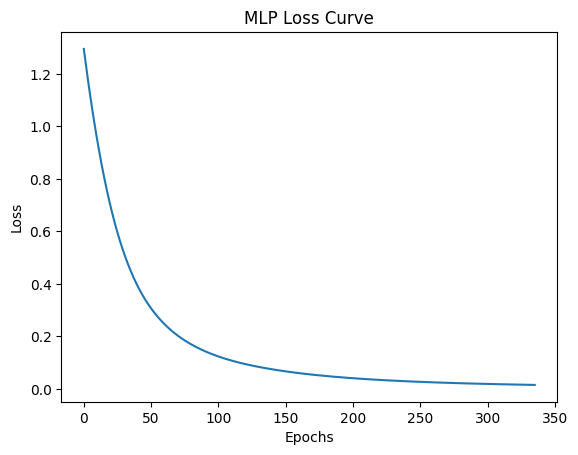

In [16]:
plt.plot(mlp.loss_curve_)
plt.title("MLP Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# STEP 9: Final Analysis

In [17]:
print("\n===== ANALYSIS =====\n")

print("1. Perceptron is a linear model.")
print("2. It struggles with complex patterns.")
print("3. MLP introduces hidden layers.")
print("4. Hidden layers learn non-linear relationships.")
print("5. MLP performs better than perceptron.")


===== ANALYSIS =====

1. Perceptron is a linear model.
2. It struggles with complex patterns.
3. MLP introduces hidden layers.
4. Hidden layers learn non-linear relationships.
5. MLP performs better than perceptron.
